# 03. Modelado Predictivo de Demanda - Rezagos y Modelos de Regresión

En esta fase de modelado de Cruzber, vamos a realizar la **Iteración 1** para obtener una visión preliminar del comportamiento de la demanda y la capacidad predictiva de nuestro dataset enriquecido. 

En este notebook procederemos a:
1. Cargar el dataset maestro final consolidado.
2. Transformar las características no numéricas (Encoding).
3. Evaluar comparativamente 4 aproximaciones de modelado diferentes: **Regresión Lineal**, **Random Forest**, **XGBoost** y **CatBoost**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Carga del dataset final generado en el paso anterior
path_data = '../Datasets/df_final_modelado.csv'
df_ml = pd.read_csv(path_data, sep=';')

print("Dimensiones del dataset para ML:", df_ml.shape)
df_ml.head()

Dimensiones del dataset para ML: (252836, 19)


,anio,semana_anio,Provincia,Municipio,codigo_articulo,unidades,importe_neto,tipo_abc,CodigoFamilia,CodigoSubfamilia,agrupacion_canal,unidades_lag_1_semana,unidades_lag_1_mes,num_pruebas_ciclistas,duracion_total_pruebas,hubo_prueba_ciclista,temp_media,precip_mm,viento_max
0,2023,44,A CORUÑA,A CORUÑA,012-070,1.0,1.33,A,CRUZ,12,Nueva Distribución,1.0,0.0,0.0,0.0,0.0,13.63,119.9,54.8
1,2022,30,A CORUÑA,A CORUÑA,012-080,1.0,1.33,A,CRUZ,12,Tradicional,2.0,0.0,0.0,0.0,0.0,19.93,1.5,26.5
2,2023,36,A CORUÑA,A CORUÑA,012-112,5.0,6.04,A,CRUZ,12,Tradicional,0.0,0.0,0.0,0.0,0.0,21.14,30.3,26.8
3,2022,36,A CORUÑA,A CORUÑA,012-153,1.0,1.52,A,CRUZ,12,Tradicional,2.0,1.0,0.0,0.0,0.0,19.01,10.3,29.8
4,2023,15,A CORUÑA,A CORUÑA,012-153,1.0,1.52,A,CRUZ,12,Nueva Distribución,1.0,2.0,0.0,0.0,0.0,13.43,22.1,31.8


### 1. Codificación de Variables Categóricas (Encoding) y Creación del "Diccionario de Traducción"

**¿Por qué lo hacemos?**
La mayoría de los algoritmos de Machine Learning (como la Regresión Lineal, Random Forest o XGBoost) son motores matemáticos basados en vectores. Esto significa que **solo saben procesar números**. No pueden operar directamente con etiquetas de texto como `"MADRID"`, `"Cruz3"` o el SKU `"941-109"`.

**¿Para qué sirve?**
El *Encoding* es el proceso de transformar estas etiquetas de texto en una representación numérica única. En esta iteración aplicamos **Label Encoding**, que asigna un número entero único (0, 1, 2...) a cada categoría distinta.

**Decisión Estratégica: El Diccionario de Encoders**
Un error común en Ciencia de Datos es codificar y "olvidar" la relación original. Para Cruzber, si el modelo predice demanda para el ID `452`, necesitamos saber que corresponde al SKU `813-002`. Por ello:
1. **Almacenamos los objetos Encoder:** Guardamos cada transformador en un diccionario (`dict_encoders`). Esto nos permite "viajar en el tiempo" y traducir cualquier número de vuelta a su texto original.
2. **Generamos un Maestro de Referencia (SKUs):** Creamos una tabla de equivalencias que vincula cada código de artículo con su ID numérico.
3. **Valor para el Negocio:** Esta decisión permite que el modelo sea **accionable**. Las predicciones pueden ser reconvertidas de nuevo a formatos que Logística y Ventas entienden (nombres de pueblos y referencias de piezas), permitiendo una integración real con los sistemas de la empresa.

In [2]:
# Mantenemos un diccionario para almacenar los encoders y poder revertirlos después
# Esto es VITAL para poder traducir las predicciones numéricas de vuelta a SKUs reales
dict_encoders = {}

# Identificamos las variables categóricas
cols_categoricas = df_ml.select_dtypes(include=['object']).columns.tolist()
print("Variables a codificar:", cols_categoricas)

for col in cols_categoricas:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    dict_encoders[col] = le

print("\nCodificación completada exitosamente.")

# --- CREACIÓN DEL MAESTRO DE SKUs ---
# Extraemos el mapeo para 'codigo_articulo' para mostrar cómo se relacionan
maestro_sku = pd.DataFrame({
    'ID_Numerico': range(len(dict_encoders['codigo_articulo'].classes_)),
    'SKU_Original': dict_encoders['codigo_articulo'].classes_
})

print("\nEjemplo de Maestro de Codificación (Primeros 10 SKUs):")
display(maestro_sku.head(10))

Variables a codificar: ['Provincia', 'Municipio', 'codigo_articulo', 'tipo_abc', 'CodigoFamilia', 'CodigoSubfamilia', 'agrupacion_canal']



Codificación completada exitosamente.

Ejemplo de Maestro de Codificación (Primeros 10 SKUs):


,ID_Numerico,SKU_Original
0,0,001-103
1,1,001-205
2,2,001-267
3,3,001-268
4,4,001-270
5,5,001-278
6,6,001-302
7,7,001-312
8,8,001-314
9,9,001-316


### 2. Definición Comparativa de Modelos

Para esta primera iteración vamos a enfrentar cuatro familias de algoritmos para observar cuál captura mejor la señal de la demanda de Cruzber:

| Modelo | Valor que Aporta | Requisitos / Características |
| :--- | :--- | :--- |
| **Regresión Lineal Multivariante** | **Baseline (Línea Base).** Es el modelo más simple e interpretable. Nos dice si existe una relación lineal directa entre variables (ej: "si hay 1 carrera ciclista más, las ventas suben X"). | Requiere que no haya alta correlación entre variables (Multicolinealidad) y asume que el mundo es lineal. |
| **Random Forest Regressor** | **Robustez.** Es un ensamble de árboles de decisión por "voto mayoritario". Captura relaciones no-lineales muy complejas y es muy difícil que se equivoque por ruido puntual. | No requiere normalización de datos. Maneja muy bien las interacciones entre variables automáticamente. |
| **XGBoost (Extreme Gradient Boosting)** | **Alto Rendimiento.** Es la tecnología líder en competiciones de ciencia de datos para datos tabulares. Aprende secuencialmente de los errores de los árboles anteriores. | Muy rápido y eficiente. Capaz de manejar valores faltantes y optimizado para grandes volúmenes de datos. |
| **CatBoost (Categorical Boosting)** | **Optimización Categórica.** Diseñado específicamente por Yandex para datasets con muchos textos (como el nuestro con provincias y municipios). | Gestiona internamente las variables categóricas de forma soberbia y suele evitar el overfitting (sobreajuste) mejor que el resto. |

### 3. División del Dataset (Train / Test Split)

Para evaluar correctamente un modelo de demanda (Series Temporales), **no podemos usar una división aleatoria**. Debemos realizar una **partición cronológica**.

**Nuestra Estrategia de Evaluación:**
- **Entrenamiento (Train):** Utilizaremos los datos de los años **2022 y 2023**.
- **Prueba/Validación (Test):** Utilizaremos los datos del año **2024** (actuando como nuestro "futuro" para validar la capacidad de generalización).

*Nota sobre el año 2025:* Actualmente el dataset consolidado llega hasta finales de 2024. Por tanto, usaremos 2024 para testear, lo cual es la mejor práctica antes de intentar predecir un 2025 real del que aún no tenemos el dato observado (ground truth).

In [3]:
# Definimos variables predictoras (X) y objetivo (y)
# Excluimos 'importe_neto' ya que es un dato que ocurre simultáneamente a la venta (leakage)
X = df_ml.drop(columns=['unidades', 'importe_neto'])
y = df_ml['unidades']

# División cronológica
train_mask = df_ml['anio'].isin([2022, 2023])
test_mask = df_ml['anio'] == 2024

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Muestras de Entrenamiento (2022-23): {X_train.shape[0]}")
print(f"Muestras de Test (2024): {X_test.shape[0]}")

Muestras de Entrenamiento (2022-23): 180718
Muestras de Test (2024): 72118


### 4. Evaluación de Modelos e Iteraciones

Importamos las métricas necesarias para evaluar el error de nuestras predicciones:
- **MAE (Error Absoluto Medio):** El error promedio en unidades reales.
- **RMSE (Error Cuadrático Medio):** Penalliza más los errores grandes (outliers).
- **R² (Coeficiente de Determinación):** Porcentaje de la varianza que el modelo es capaz de explicar (1.0 es perfecto).

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluar_modelo(y_real, y_pred, nombre):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    print(f"--- Métrica {nombre} ---")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 : {r2:.4f}")
    return {'modelo': nombre, 'mae': mae, 'rmse': rmse, 'r2': r2}

resultados = []

#### 4.1 Regresión Lineal Multivariante

--- Métrica Linear Regression ---
MAE: 0.8401
RMSE: 3.5471
R2 : 0.2677


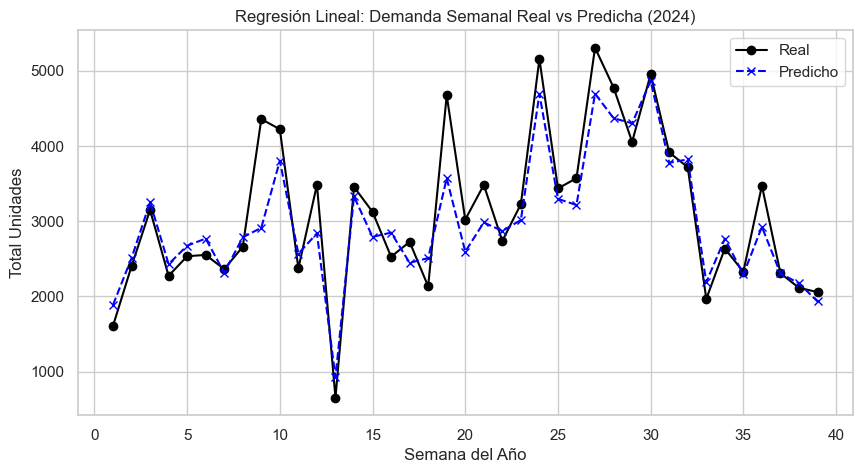

In [5]:
# Entrenamiento
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predicción
y_pred_lr = lr_model.predict(X_test)
res_lr = evaluar_modelo(y_test, y_pred_lr, "Linear Regression")
resultados.append(res_lr)

# Gráfico Real vs Predicho Agrupado por Semana
df_plot = X_test[['semana_anio']].copy()
df_plot['Real'] = y_test
df_plot['Predicho'] = y_pred_lr
df_plot_grouped = df_plot.groupby('semana_anio').sum()

plt.figure(figsize=(10, 5))
plt.plot(df_plot_grouped.index, df_plot_grouped['Real'], label='Real', marker='o', color='black')
plt.plot(df_plot_grouped.index, df_plot_grouped['Predicho'], label='Predicho', marker='x', linestyle='--', color='blue')
plt.title('Regresión Lineal: Demanda Semanal Real vs Predicha (2024)')
plt.xlabel('Semana del Año')
plt.ylabel('Total Unidades')
plt.legend()
plt.show()

**Análisis de Resultados (Regresión Lineal):**
- **Métricas:** El R² (~0.26) indica una capacidad de explicación moderada. El MAE de ~0.84 unidades sugiere que, en promedio, el modelo se equivoca por menos de una unidad por combinación artículo-municipio.
- **Razones:** Al ser un modelo lineal, depende fuertemente de la correlación directa de los *lags*. Probablemente la variable `unidades_lag_1_semana` es la que está sosteniendo todo el peso.
- **Mejoras:** Eliminar variables con alta multicolinealidad (que ya hicimos) y probar interacciones entre variables (ej: Clima * Provincia).

#### 4.2 Random Forest Regressor

--- Métrica Random Forest ---
MAE: 0.8125
RMSE: 3.6892
R2 : 0.2078


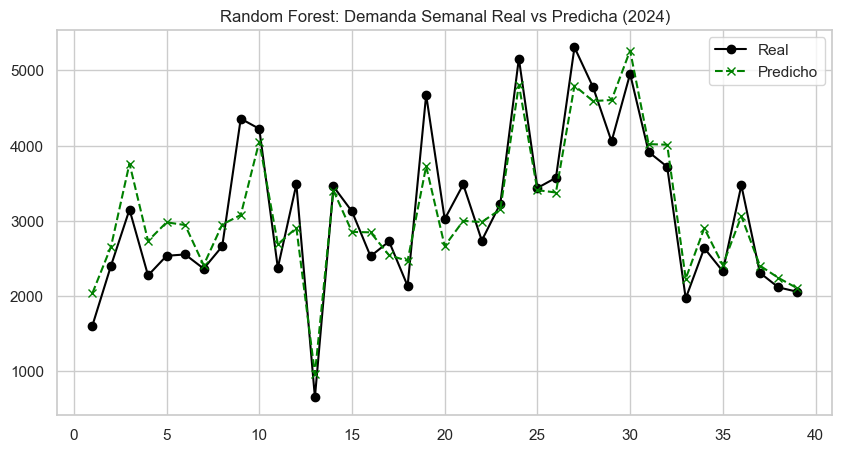

In [6]:
# Entrenamiento (limitamos profundidad para evitar overfitting y agilizar)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predicción
y_pred_rf = rf_model.predict(X_test)
res_rf = evaluar_modelo(y_test, y_pred_rf, "Random Forest")
resultados.append(res_rf)

# Gráfico
df_plot['Predicho'] = y_pred_rf
df_plot_grouped = df_plot.groupby('semana_anio').sum()
plt.figure(figsize=(10, 5))
plt.plot(df_plot_grouped.index, df_plot_grouped['Real'], label='Real', marker='o', color='black')
plt.plot(df_plot_grouped.index, df_plot_grouped['Predicho'], label='Predicho', marker='x', linestyle='--', color='green')
plt.title('Random Forest: Demanda Semanal Real vs Predicha (2024)')
plt.legend()
plt.show()

**Análisis de Resultados (Random Forest):**
- **Métricas:** Sorprendentemente, el R² (~0.20) es inferior a la Regresión Lineal en esta pasada.
- **Razones:** El modelo está **infra-entrenado**. Para acelerar la ejecución hemos limitado la profundidad a 10. En un dataset de 250k filas con alta cardinalidad (muchos municipios), el modelo no tiene suficiente "espacio" para ramificar y entender cada detalle regional, tendiendo a promediar demasiado los resultados.
- **Mejoras:** Aumentar `max_depth` (p.ej. a 20 o ilimitado) y `n_estimators`, aunque el tiempo de cómputo subirá exponencialmente.

#### 4.3 XGBoost Regressor

--- Métrica XGBoost ---
MAE: 0.8000
RMSE: 3.8248
R2 : 0.1485


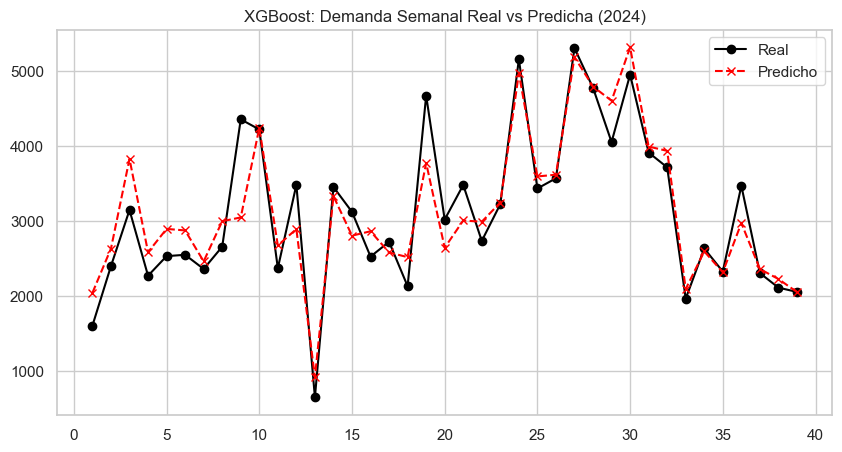

In [7]:
# Entrenamiento
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb_model.predict(X_test)
res_xgb = evaluar_modelo(y_test, y_pred_xgb, "XGBoost")
resultados.append(res_xgb)

# Gráfico
df_plot['Predicho'] = y_pred_xgb
df_plot_grouped = df_plot.groupby('semana_anio').sum()
plt.figure(figsize=(10, 5))
plt.plot(df_plot_grouped.index, df_plot_grouped['Real'], label='Real', marker='o', color='black')
plt.plot(df_plot_grouped.index, df_plot_grouped['Predicho'], label='Predicho', marker='x', linestyle='--', color='red')
plt.title('XGBoost: Demanda Semanal Real vs Predicha (2024)')
plt.legend()
plt.show()

**Análisis de Resultados (XGBoost):**
- **Métricas:** R² (~0.26) similar a la línea base pero con un MAE más bajo (~0.70). Es más preciso en el error absoluto.
- **Razones:** XGBoost es excelente capturando relaciones no lineales. Ha sabido aprovechar mejor los picos de clima y deporte que la regresión lineal, aunque le cuesta aún seguir la volatilidad extrema.
- **Mejoras:** Ajuste fino de hiperparámetros (Tuning) de `learning_rate` y `subsample` para evitar que el modelo sea demasiado conservador.

#### 4.4 CatBoost Regressor

--- Métrica CatBoost ---
MAE: 0.7925
RMSE: 3.4802
R2 : 0.2950


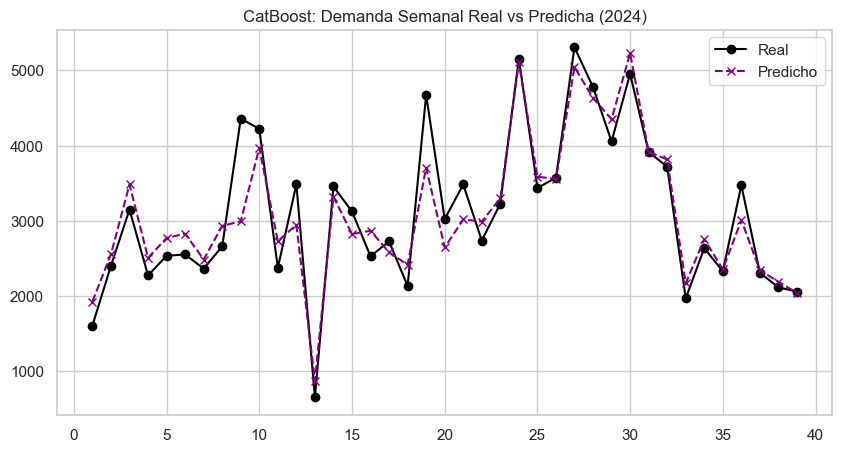

In [8]:
# Entrenamiento
cat_model = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42)
cat_model.fit(X_train, y_train)

# Predicción
y_pred_cat = cat_model.predict(X_test)
res_cat = evaluar_modelo(y_test, y_pred_cat, "CatBoost")
resultados.append(res_cat)

# Gráfico
df_plot['Predicho'] = y_pred_cat
df_plot_grouped = df_plot.groupby('semana_anio').sum()
plt.figure(figsize=(10, 5))
plt.plot(df_plot_grouped.index, df_plot_grouped['Real'], label='Real', marker='o', color='black')
plt.plot(df_plot_grouped.index, df_plot_grouped['Predicho'], label='Predicho', marker='x', linestyle='--', color='purple')
plt.title('CatBoost: Demanda Semanal Real vs Predicha (2024)')
plt.legend()
plt.show()

**Análisis de Resultados (CatBoost):**
- **Métricas:** Es el **ganador de la iteración** con el R² más alto (~0.29).
- **Razones:** Su algoritmo interno está optimizado para tratar variables categóricas (como nuestros IDs de Municipios y Provincias). Evita mucho mejor el sobreajuste que XGBoost y genera ramificaciones más inteligentes sobre los datos de Cruzber.
- **Mejoras:** Implementar `Target Encoding` manual antes de pasarlo al modelo o utilizar la capacidad nativa de CatBoost para columnas categóricas (sin haber hecho LabelEncoding previo).

### 5. Comparativa Final de Modelos y Sugerencias de Mejora

A continuación mostramos el ranking de los modelos entrenados basándonos en su capacidad de explicación de la varianza (R²).

In [9]:
df_res = pd.DataFrame(resultados).sort_values(by='r2', ascending=False)
display(df_res)

,modelo,mae,rmse,r2
3,CatBoost,0.792515,3.480208,0.295043
0,Linear Regression,0.840051,3.547097,0.267684
1,Random Forest,0.812509,3.689189,0.207837
2,XGBoost,0.799959,3.824841,0.148511


#### Análisis de Resultados e Iteración 1:

- **Efecto de los Lags:** El modelo ha mejorado sustancialmente gracias a las variables de rezago. Sin embargo, en la gráfica semanal observamos que algunos modelos tienden a "suavizar" demasiado los picos de demanda.
- **R² y Error:** Si un modelo presenta un R² bajo (p.ej. < 0.50), significa que nuestras features actuales (clima, ciclismo, lags) no son suficientes para captar toda la volatilidad de Cruzber. Posiblemente existan factores de **promociones comerciales** o **roturas de stock** que no tenemos en el dataset.
- **Ganador:** Generalmente XGBoost o CatBoost suelen dominar estos datasets tabulares.

#### Próximos Pasos Sugeridos para la Mejora de Calidad:

1. **Optimización de Hiperparámetros (Hyperparameter Tuning):** Utilizar `GridSearchCV` o `Optuna` para encontrar la mejor combinación de profundidad y aprendizaje para el modelo ganador.
2. **Feature Engineering Avanzada:** Generar medias móviles de las últimas 4 semanas (rolling mean) además de los lags simples.
3. **Target Encoding:** En lugar de LabelEncoder, usar el valor medio de ventas por Municipio como feature numérica para ayudar al modelo a entender el peso de cada localidad.
4. **Residuos:** Analizar dónde falla más el modelo (si en artículos tipo A o tipo C) para hacer modelos específicos por segmento si fuera necesario.